In [ ]:
import pandas as pd
import numpy as np

In [4]:
ratings= pd.read_csv("ratings.csv")
movies= pd.read_csv("movies.csv")

In [5]:
data= pd.merge(ratings, movies, on="movieId")
print(data.head())

   userId  movieId  rating   timestamp  \
0       1       31     2.5  1260759144   
1       1     1029     3.0  1260759179   
2       1     1061     3.0  1260759182   
3       1     1129     2.0  1260759185   
4       1     1172     4.0  1260759205   

                                            title  \
0                          Dangerous Minds (1995)   
1                                    Dumbo (1941)   
2                                 Sleepers (1996)   
3                     Escape from New York (1981)   
4  Cinema Paradiso (Nuovo cinema Paradiso) (1989)   

                             genres  
0                             Drama  
1  Animation|Children|Drama|Musical  
2                          Thriller  
3  Action|Adventure|Sci-Fi|Thriller  
4                             Drama  


In [10]:
from sklearn.metrics.pairwise import cosine_similarity
user_movie_matrix= data.pivot_table(
    index="userId",
    columns="title",
    values="rating"
)
user_movie_matrix= user_movie_matrix.fillna(0)

In [8]:
print(data.columns)

Index(['userId', 'movieId', 'rating', 'timestamp', 'title', 'genres'], dtype='str')


In [11]:
user_similarity= cosine_similarity(user_movie_matrix)

user_similarity_df= pd.DataFrame(
    user_similarity,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.index
)

In [12]:
similar_users= user_similarity_df[1].sort_values(ascending=False)
print(similar_users.head(10))

userId
1      1.000000
325    0.371852
634    0.194093
341    0.162819
310    0.157524
207    0.152746
35     0.130585
195    0.122647
485    0.114021
130    0.112817
Name: 1, dtype: float64


In [17]:
def recommend_movies(user_id, num_recommendtions=5):

    similar_users=user_similarity_df[user_id].sort_values(ascending=False)[1:6]
    similar_user_ratings=user_movie_matrix.loc[similar_users.index]
    weighted_rating= similar_user_ratings.T.dot(similar_users)/ similar_users.sum()
    user_ratings= user_movie_matrix.loc[user_id]
    recommendations= weighted_rating[user_ratings==0]
    top_recommendations= recommendations.sort_values(ascending=False).head(num_recommendtions)
    return recommendations.sort_values(ascending=False).head(num_recommendtions)
    return top_recommendations

print(recommend_movies(1))

title
Beverly Hills Cop (1984)           2.549889
Brady Bunch Movie, The (1995)      1.618329
My Best Friend's Wedding (1997)    1.431528
Junior (1994)                      1.234251
Trading Places (1983)              1.073646
dtype: float64


In [18]:
def precision_at_k(recommended, relevant, k):
    recommended_k= recommended[:k]
    relevant_set= set(relevant)
    recommended_set= set(recommended_k)
    
    hits= len(set(recommended_k)& relevant_set)
    return hits/k
    

In [19]:
item_similarity= cosine_similarity(user_movie_matrix.T)

In [21]:
from sklearn.decomposition import TruncatedSVD

In [22]:
svd= TruncatedSVD(n_components=20)
matrix= svd.fit_transform(user_movie_matrix)

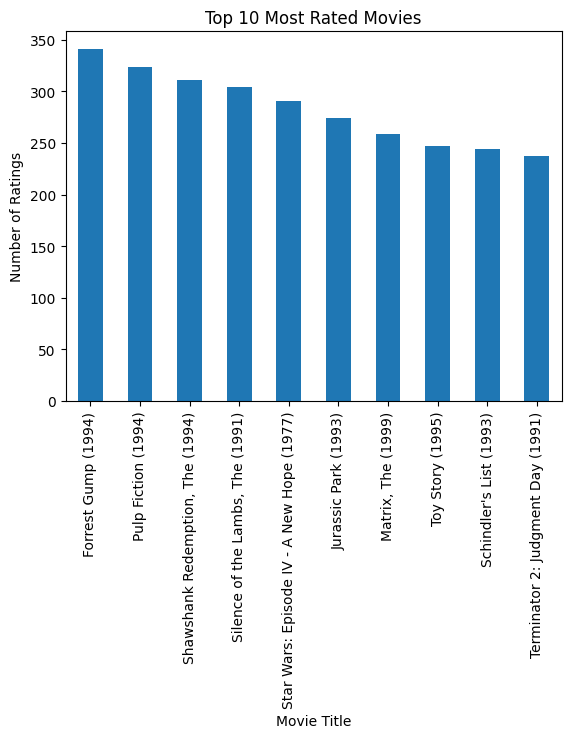

In [23]:
import matplotlib.pyplot as plt
data['title'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Most Rated Movies')
plt.xlabel('Movie Title')
plt.ylabel('Number of Ratings')
plt.show()